In [9]:
!pip install numpy pandas scikit-fuzzy scipy networkx matplotlib

Defaulting to user installation because normal site-packages is not writeable


### Tahap 1 - Import Library dan Dataset

In [19]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data.csv')

# Cek kolom (PENTING: Pastikan nama kolom di CSV sesuai: C1, C2, C3, C4, C5)
print("Data berhasil dimuat! Menampilkan 5 baris pertama:")
df.head()

Data berhasil dimuat! Menampilkan 5 baris pertama:


,No,ID_Alternatif,Moda_Transportasi,C1_Waktu,C2_Biaya,C3_Cuaca,C4_Kapasitas,C5_Medan
0,1,A001,Petrol Jeep,86,1787,4,4,2
1,2,A002,Motorcycle (Cargo),50,789,5,3,2
2,3,A003,EV Delivery,52,1798,2,4,1
3,4,A004,Motorcycle (Cargo),118,479,4,1,5
4,5,A005,Motorcycle (Cargo),98,1668,4,4,3


### Tahap 2 - Definisi Semesta Pembicaraan (Universe)

In [20]:
# Antecedent adalah INPUT
waktu = ctrl.Antecedent(np.arange(0, 151, 1), 'C1')    # Waktu 0-150 menit
biaya = ctrl.Antecedent(np.arange(0, 2001, 1), 'C2')   # Biaya 0-2000 ribu
cuaca = ctrl.Antecedent(np.arange(1, 6, 1), 'C3')      # Skala 1-5
kapasitas = ctrl.Antecedent(np.arange(1, 6, 1), 'C4')  # Skala 1-5
medan = ctrl.Antecedent(np.arange(1, 6, 1), 'C5')      # Skala 1-5

# Consequent adalah OUTPUT
skor = ctrl.Consequent(np.arange(0, 101, 1), 'skor')    # Skor 0-100

### Tahap 3 - Membership Function (Minimal 3 Fungsi per Variabel)

In [21]:
# C1: Waktu (Cepat, Sedang, Lambat)
waktu['cepat'] = fuzz.trimf(waktu.universe, [0, 0, 60])
waktu['sedang'] = fuzz.trapmf(waktu.universe, [40, 60, 90, 110])
waktu['lambat'] = fuzz.trimf(waktu.universe, [90, 150, 150])

# C2: Biaya (Murah, Standar, Mahal)
biaya['murah'] = fuzz.trimf(biaya.universe, [0, 0, 800])
biaya['standar'] = fuzz.trimf(biaya.universe, [500, 1000, 1500])
biaya['mahal'] = fuzz.trimf(biaya.universe, [1200, 2000, 2000])

# C3, C4, C5: (Buruk, Cukup, Bagus)
for k in [cuaca, kapasitas, medan]:
    k['buruk'] = fuzz.trimf(k.universe, [1, 1, 3])
    k['cukup'] = fuzz.trimf(k.universe, [2, 3, 4])
    k['bagus'] = fuzz.trimf(k.universe, [3, 5, 5])

# Output Skor (Rendah, Menengah, Tinggi)
skor['rendah'] = fuzz.trimf(skor.universe, [0, 0, 50])
skor['menengah'] = fuzz.trimf(skor.universe, [30, 50, 70])
skor['tinggi'] = fuzz.trimf(skor.universe, [50, 100, 100])

### Tahap 4 - Basis Aturan

In [22]:
rules = [
    ctrl.Rule(waktu['cepat'] & biaya['murah'], skor['tinggi']),
    ctrl.Rule(waktu['lambat'] | biaya['mahal'], skor['rendah']),
    ctrl.Rule(cuaca['buruk'] & medan['buruk'], skor['rendah']),
    ctrl.Rule(kapasitas['bagus'] & medan['bagus'], skor['tinggi']),
    ctrl.Rule(waktu['sedang'] & biaya['standar'], skor['menengah']),
    ctrl.Rule(cuaca['bagus'] & kapasitas['bagus'], skor['tinggi']),
    ctrl.Rule(medan['cukup'] & biaya['standar'], skor['menengah']),
    ctrl.Rule(waktu['cepat'] & cuaca['cukup'], skor['tinggi']),
    ctrl.Rule(kapasitas['buruk'] | biaya['mahal'], skor['rendah']),
    ctrl.Rule(medan['bagus'] & waktu['sedang'], skor['tinggi'])
]

sistem_kontrol = ctrl.ControlSystem(rules)
simulasi = ctrl.ControlSystemSimulation(sistem_kontrol)

### Tahap 5 - Komputasi Fuzzy untuk 250 Data

In [23]:
hasil_akhir = []

for index, row in df.iterrows():
    # Masukkan input dari baris CSV
    simulasi.input['C1'] = row['C1_Waktu']
    simulasi.input['C2'] = row['C2_Biaya']
    simulasi.input['C3'] = row['C3_Cuaca']
    simulasi.input['C4'] = row['C4_Kapasitas']
    simulasi.input['C5'] = row['C5_Medan']
    
    try:
        simulasi.compute()
        hasil_akhir.append(simulasi.output['skor'])
    except:
        hasil_akhir.append(0) # Skor 0 jika tidak kena rule manapun

# Masukkan ke kolom baru dan sorting
df['Skor_Mamdani'] = hasil_akhir
df_final = df.sort_values(by='Skor_Mamdani', ascending=False)
df_final.head(10)

,No,ID_Alternatif,Moda_Transportasi,C1_Waktu,C2_Biaya,C3_Cuaca,C4_Kapasitas,C5_Medan,Skor_Mamdani
53,54,A054,Motorcycle (Cargo),55,302,5,5,3,83.333333
168,169,A169,Petrol Jeep,61,241,1,3,5,83.333333
189,190,A190,Motorcycle (Cargo),61,123,2,4,5,83.333333
239,240,A240,Motorcycle (Cargo),90,133,3,3,5,83.333333
167,168,A168,Small Truck,20,134,2,5,3,81.944444
192,193,A193,Van,20,141,1,5,4,81.944444
139,140,A140,Van,91,241,2,5,5,81.460145
224,225,A225,Motorcycle (Cargo),25,233,4,4,5,81.290850
147,148,A148,Petrol Jeep,20,345,5,3,1,81.167667
157,158,A158,Petrol Jeep,20,345,5,3,1,81.167667


### Tahap 6 - Visualisasi Kurva (Output Modul)

C:\Users\biyanbaru\AppData\Roaming\Python\Python313\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


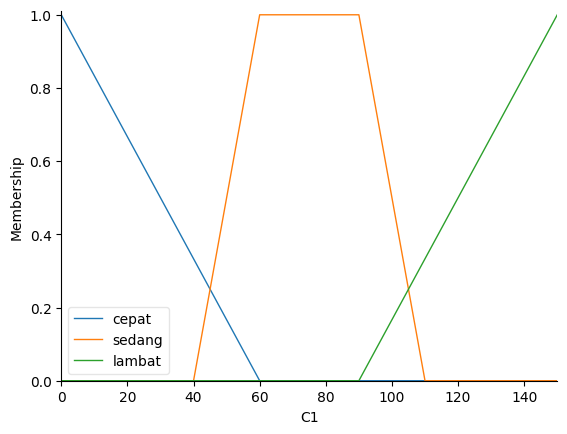

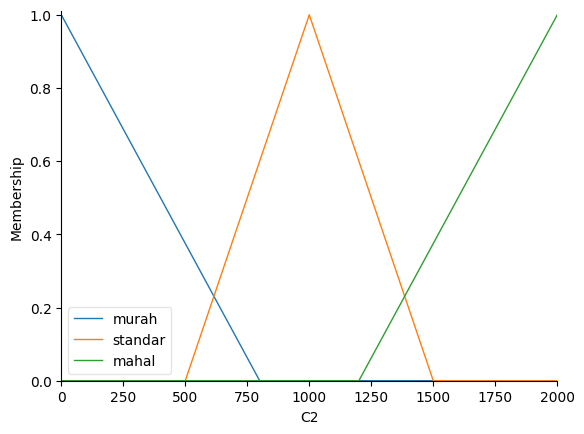

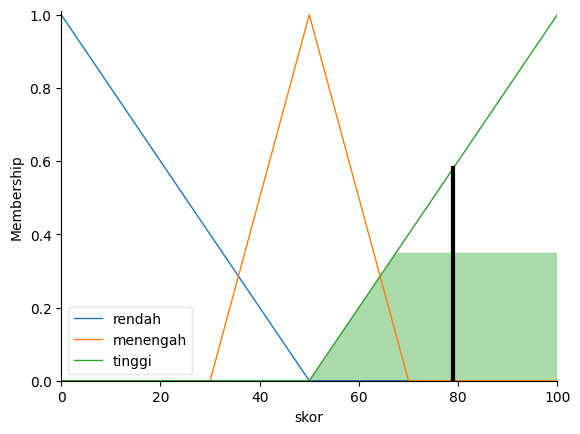

In [24]:
waktu.view()
biaya.view()
skor.view(sim=simulasi)

### Tahap 7 - Export ke app.py

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# (Di sini nanti Andini tinggal tambahkan layout Streamlit-nya)
st.title("Pemilihan Moda Transportasi Darurat untuk Distribusi Obat ke Daerah Terpencil Saat Bencana")
st.write("Dibuat oleh: Biyan & Andini")

Overwriting app.py
